In [61]:
import numpy as np
import pandas as pd


In [62]:
open_file_name = 'final_cleaned_compiled.csv'
output_file_name = 'converted.csv'

In [106]:
df = pd.read_csv(open_file_name)
df.head(10)

,Translated Time,Translated Time (minutes),ADS Reading 1 (Smoothed and Offset),Calibrated Current 1,ADS Reading 2 (Smoothed and Offset),Calibrated Current 2,ADS Reading 3 (Smoothed),Calibrated Voltage
0,1000,0.016667,2.863429,0.008564,4.816303,0.014406,25542.0,57.46950
1,1032,0.017200,-1.136571,-0.003399,4.816303,0.014406,25541.5,57.46950
2,1064,0.017733,1.863429,0.005573,4.816303,0.014406,25541.0,57.46500
3,1095,0.018250,1.863429,0.005573,4.816303,0.014406,25541.0,57.46725
4,1126,0.018767,-3.136571,-0.009381,4.816303,0.014406,25541.0,57.46725
5,1157,0.019283,-4.136571,-0.012372,4.816303,0.014406,25541.0,57.46725
6,1189,0.019817,-3.136571,-0.009381,4.816303,0.014406,25541.0,57.46725
7,1220,0.020333,-3.136571,-0.009381,4.816303,0.014406,25541.0,57.46725
8,1251,0.020850,2.863429,0.008564,4.816303,0.014406,25541.0,57.46725
9,1283,0.021383,3.863429,0.011555,4.816303,0.014406,25541.0,57.46725


In [107]:
df['Calibrated Voltage']/12 


0         4.789125
1         4.789125
2         4.788750
3         4.788938
4         4.788938
            ...   
623037    1.746750
623038    1.746750
623039    1.746750
623040    1.746750
623041    1.746750
Name: Calibrated Voltage, Length: 623042, dtype: float64

In [108]:
def voltage_to_adc(v, range):
    if range == 0 or range == 5:
        fs = 2.5
    elif range == 1 or range == 6:
        fs = 1.25
    elif range == 2 or range == 7:
        fs = 0.625  
    elif range == 3 or range == 8:
        fs = 0.3125
    elif range == 4:
        fs = 0.15625
    else: 
        raise ValueError("Invalid range value. Must be between 0 and 4.")
    fs *= 4.096
    
    if range >= 0 and range <= 4:
        if v < -fs:
            clamped = -fs
        elif v > fs:
            clamped = fs
        else:
            clamped = v
        return 32768 + (clamped / fs * 32768)
    else:
        clamped = max(0, min(v, fs))
        return clamped / fs * 65535

In [113]:
def current_to_adc(current):
    #current = 0.90225289 * x**2 + 15.06345527*x, x = voltage
    
    a = 0.90225289
    b = 15.06345527
    c = -abs(current)
    
    discriminant = b**2 - 4*a*c
    if discriminant < 0:
        raise ValueError("Current value is out of range for the quadratic equation.")
    
    voltage = (-b + np.sqrt(discriminant)) / (2*a)
    adc_val = voltage_to_adc(voltage if current >= 0 else -voltage, 1)
    return adc_val    

In [114]:
from random import random


new_df = pd.DataFrame(columns=['counter', 'timediff_us', 'ch0', 'ch1', 'ch2', 'ch3', 'ch4', 'ch5', 'ch6', 'ch7'])
new_df['timediff_us'] = df['Translated Time'].diff() * 1000000
new_df['timediff_us'] = new_df['timediff_us'].fillna(0).astype(int)

new_df['ch0'] = 32768 - 15
new_df['ch0'] = new_df['ch0'].apply(lambda x: x + random() * 30)
new_df['ch1'] = df['Calibrated Current 1'].apply(current_to_adc)
new_df['ch2'] = (-df['Calibrated Current 2']).apply(current_to_adc)
new_df['ch3'] = 32768 - 15
new_df['ch3'] = new_df['ch3'].apply(lambda x: x + random() * 30)

new_df['ch4'] = 0
new_df['ch5'] = 0

new_df['ch6'] = (df['Calibrated Voltage'] / 6).apply(voltage_to_adc, args=(5,))
new_df['ch7'] = 100
new_df['ch7'] = new_df['ch7'].apply(lambda x: x + random() * 30)

new_df['counter'] = range(1, len(new_df) + 1)


new_df.head(10)

,counter,timediff_us,ch0,ch1,ch2,ch3,ch4,ch5,ch6,ch7
0,1,0,32774.213621,32771.638632,32761.879872,32771.054381,0,0,61299.864624,108.607312
1,2,32000000,32764.421084,32766.555734,32761.879872,32757.606003,0,0,61299.864624,129.089670
2,3,32000000,32760.622564,32770.367921,32761.879872,32769.702901,0,0,61295.064697,115.320073
3,4,31000000,32781.139040,32770.367921,32761.879872,32764.021861,0,0,61297.464661,110.405374
4,5,31000000,32754.769123,32764.014432,32761.879872,32760.562858,0,0,61297.464661,100.659458
5,6,31000000,32754.353059,32762.743849,32761.879872,32776.760944,0,0,61297.464661,124.944149
6,7,32000000,32764.133067,32764.014432,32761.879872,32756.547040,0,0,61297.464661,106.785900
7,8,31000000,32775.404745,32764.014432,32761.879872,32760.101620,0,0,61297.464661,113.182784
8,9,31000000,32756.776771,32771.638632,32761.879872,32775.075365,0,0,61297.464661,126.445836
9,10,32000000,32773.144435,32772.909329,32761.879872,32777.613055,0,0,61297.464661,111.866602


In [117]:
(-df['Calibrated Current 2']).apply(current_to_adc).apply(adc_to_current, args=(1,))

0        -0.014406
1        -0.014406
2        -0.014406
3        -0.014406
4        -0.014406
            ...   
623037   -0.464382
623038   -0.464382
623039   -0.464382
623040   -0.462884
623041   -0.461386
Name: Calibrated Current 2, Length: 623042, dtype: float64

In [ ]:
(-df['Calibrated Current 2']).apply(current_to_adc)

In [118]:
V_REF = 4.096

def adc_to_voltage(adc_value, range):
    if range == 0 or range == 5:
        fs = 2.5 * V_REF
    elif range == 1 or range == 6:
        fs = 1.25 * V_REF
    elif range == 2 or range == 7:
        fs = 0.625 * V_REF  
    elif range == 3 or range == 8:
        fs = 0.3125 * V_REF
    elif range == 4:
        fs = 0.15625 * V_REF
    else: 
        raise ValueError("Invalid range value. Must be between 0 and 4.")
        
    if (range >= 0 and range <= 4):
        offset = adc_value - 32768
        return (offset / 32768) * fs
    else:
        return (adc_value / 65536) * fs
    


def adc_to_current(adc_value, range):
    voltage = adc_to_voltage(adc_value, range)

    if (voltage < 0):
        return -(0.90225289 * abs(voltage) ** 2 + 15.06345527 * abs(voltage))
    else:
        return 0.90225289 * voltage ** 2 + 15.06345527 * voltage

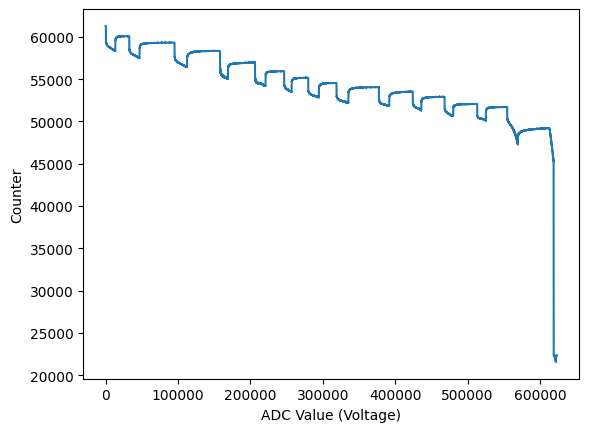

In [119]:
from matplotlib import pyplot as plt


plt.plot(new_df['counter'], new_df['ch6'])
plt.xlabel('ADC Value (Voltage)')
plt.ylabel('Counter')
plt.show()

In [137]:
new_df['ch0'] = new_df['ch0'].round().astype(int)
new_df['ch1'] = new_df['ch1'].round().astype(int)
new_df['ch2'] = new_df['ch2'].round().astype(int)
new_df['ch3'] = new_df['ch3'].round().astype(int)
new_df['ch4'] = new_df['ch4'].round().astype(int)
new_df['ch5'] = new_df['ch5'].round().astype(int)
new_df['ch6'] = new_df['ch6'].round().astype(int)
new_df['ch7'] = new_df['ch7'].round().astype(int)
new_df.head(10)


,counter,timediff_us,ch0,ch1,ch2,ch3,ch4,ch5,ch6,ch7
0,1,0,32774,32772,32762,32771,0,0,61300,109
1,2,32000000,32764,32767,32762,32758,0,0,61300,129
2,3,32000000,32761,32770,32762,32770,0,0,61295,115
3,4,31000000,32781,32770,32762,32764,0,0,61297,110
4,5,31000000,32755,32764,32762,32761,0,0,61297,101
5,6,31000000,32754,32763,32762,32777,0,0,61297,125
6,7,32000000,32764,32764,32762,32757,0,0,61297,107
7,8,31000000,32775,32764,32762,32760,0,0,61297,113
8,9,31000000,32757,32772,32762,32775,0,0,61297,126
9,10,32000000,32773,32773,32762,32778,0,0,61297,112


In [140]:
new_df = new_df[:618902]
new_df['ch2'] = 32768 - (new_df['ch2'] - 32768)


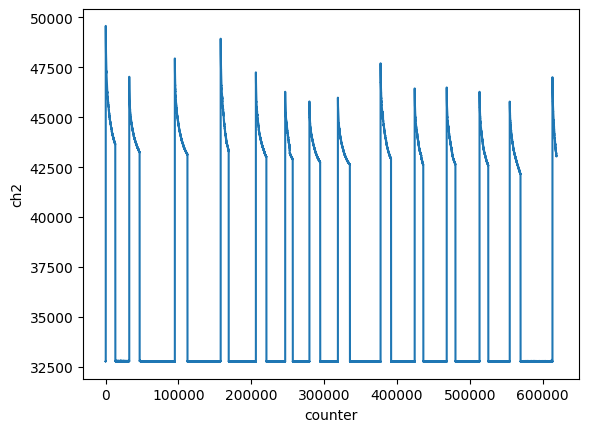

In [141]:
plt.plot(new_df['counter'], new_df['ch2'], label='ch2')
plt.xlabel('counter')
plt.ylabel('ch2')
plt.show()

In [142]:
new_df.to_csv(output_file_name, index=False)
print(f"Total rows converted: {len(new_df)}")

Total rows converted: 618902
